In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../data/processed/emails_cleaned.csv")

In [6]:
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (30763, 9)


,Message ID,Subject,Message,Spam/Ham,Date,Subject_Length,Message_Length,Text,Word_Count
0,0,christmas tree farm pictures,NaN,ham,1999-12-10,28,0,christmas tree farm pictures,4
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13,24,4282,"vastar resources , inc . gary , production fro...",1577
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14,28,38,calpine daily gas nomination - calpine daily g...,12
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14,10,1171,re : issue fyi - see note below - already done...,347
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14,25,1124,meter 7268 nov allocation fyi .\n- - - - - - -...,322


Create X and y

In [7]:
X = df["Text"]
y = df["Spam/Ham"]

In [8]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30763,)
y shape: (30763,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training samples: 24610
Testing samples: 6153

Training distribution:
Spam/Ham
ham     51.852905
spam    48.147095
Name: proportion, dtype: float64

Testing distribution:
Spam/Ham
ham     51.844629
spam    48.155371
Name: proportion, dtype: float64


TF-IDF + Naive Bayes

In [12]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", MultinomialNB())
])

In [13]:
nb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U4](2,)","['ham','spam']"
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True


In [14]:
y_pred = nb_pipeline.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="spam")
recall = recall_score(y_test, y_pred, pos_label="spam")
f1 = f1_score(y_test, y_pred, pos_label="spam")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9831
Precision: 0.9877
Recall   : 0.9771
F1 Score : 0.9824


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.98      0.99      0.98      3190
        spam       0.99      0.98      0.98      2963

    accuracy                           0.98      6153
   macro avg       0.98      0.98      0.98      6153
weighted avg       0.98      0.98      0.98      6153



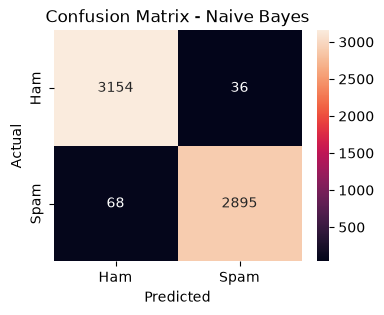

In [18]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["ham", "spam"]
)

plt.figure(figsize=(4, 3))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")

plt.show()

In [19]:
results = []

results.append({
    "Model": "Multinomial Naive Bayes",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
})

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.983098,0.987718,0.97705,0.982355


In [20]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", LogisticRegression(max_iter=1000))
])

In [21]:
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['ham','spam']"
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True


In [22]:
y_pred_lr = lr_pipeline.predict(X_test)

In [23]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, pos_label="spam")
recall_lr = recall_score(y_test, y_pred_lr, pos_label="spam")
f1_lr = f1_score(y_test, y_pred_lr, pos_label="spam")

print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1 Score : {f1_lr:.4f}")

Accuracy : 0.9837
Precision: 0.9735
Recall   : 0.9933
F1 Score : 0.9833


In [24]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         ham       0.99      0.97      0.98      3190
        spam       0.97      0.99      0.98      2963

    accuracy                           0.98      6153
   macro avg       0.98      0.98      0.98      6153
weighted avg       0.98      0.98      0.98      6153



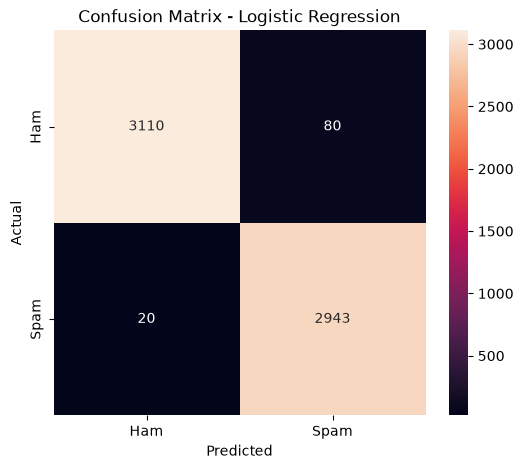

In [25]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr,
    labels=["ham", "spam"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [26]:
results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_lr,
    "Precision": precision_lr,
    "Recall": recall_lr,
    "F1 Score": f1_lr
})

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.983098,0.987718,0.97705,0.982355
1,Logistic Regression,0.983748,0.973536,0.99325,0.983294


Linear SVM

In [27]:
from sklearn.svm import LinearSVC

svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", LinearSVC())
])

In [28]:
svm_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['ham','spam']"
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True


In [30]:
y_pred_svm = svm_pipeline.predict(X_test)

In [31]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, pos_label="spam")
recall_svm = recall_score(y_test, y_pred_svm, pos_label="spam")
f1_svm = f1_score(y_test, y_pred_svm, pos_label="spam")

print(f"Accuracy : {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall   : {recall_svm:.4f}")
print(f"F1 Score : {f1_svm:.4f}")

Accuracy : 0.9901
Precision: 0.9846
Recall   : 0.9949
F1 Score : 0.9898


In [32]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

         ham       1.00      0.99      0.99      3190
        spam       0.98      0.99      0.99      2963

    accuracy                           0.99      6153
   macro avg       0.99      0.99      0.99      6153
weighted avg       0.99      0.99      0.99      6153



In [33]:
results.append({
    "Model": "Linear SVM",
    "Accuracy": accuracy_svm,
    "Precision": precision_svm,
    "Recall": recall_svm,
    "F1 Score": f1_svm
})

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.983098,0.987718,0.977050,0.982355
1,Logistic Regression,0.983748,0.973536,0.993250,0.983294
2,Linear SVM,0.990086,0.984636,0.994938,0.989760


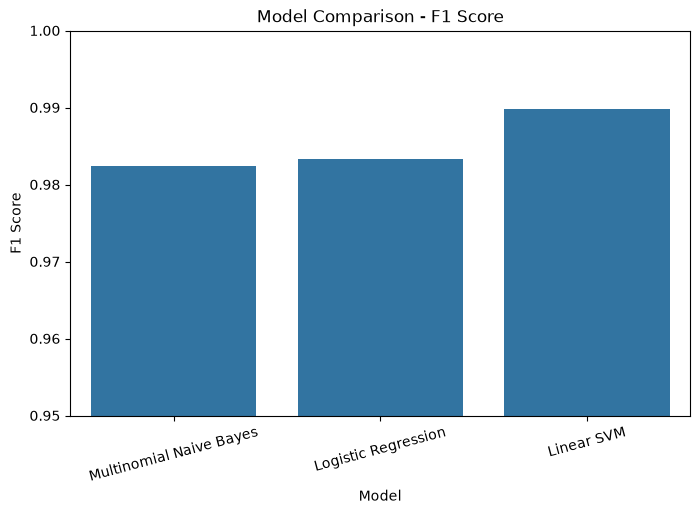

In [34]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score"
)

plt.title("Model Comparison - F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.ylim(0.95, 1.00)

plt.xticks(rotation=15)

plt.show()

In [35]:
from sklearn.model_selection import GridSearchCV

In [36]:
svm_pipeline_tuned = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", LinearSVC())
])

In [37]:
param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 5],
    "tfidf__sublinear_tf": [True, False],
    "model__C": [0.5, 1, 2]
}

In [45]:
from sklearn.metrics import make_scorer

f1_spam = make_scorer(
    f1_score,
    pos_label="spam"
)

In [46]:
grid_search = GridSearchCV(
    svm_pipeline_tuned,
    param_grid,
    cv=3,
    scoring=f1_spam,
    n_jobs=-1,
    verbose=1
)

In [47]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...LinearSVC())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.5, 1, ...], 'tfidf__min_df': [1, 2, ...], 'tfidf__ngram_range': [(1, ...), (1, ...)], 'tfidf__sublinear_tf': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...os_label=spam)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metri

In [48]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV F1:")
print(grid_search.best_score_)

Best parameters:
{'model__C': 1, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}

Best CV F1:
0.9910982581301638


In [49]:
best_svm = grid_search.best_estimator_

In [50]:
y_pred_tuned = best_svm.predict(X_test)

In [51]:
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(
    y_test,
    y_pred_tuned,
    pos_label="spam"
)
recall_tuned = recall_score(
    y_test,
    y_pred_tuned,
    pos_label="spam"
)
f1_tuned = f1_score(
    y_test,
    y_pred_tuned,
    pos_label="spam"
)

print(f"Accuracy : {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall   : {recall_tuned:.4f}")
print(f"F1 Score : {f1_tuned:.4f}")

Accuracy : 0.9915
Precision: 0.9873
Recall   : 0.9953
F1 Score : 0.9913


In [52]:
print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

         ham       1.00      0.99      0.99      3190
        spam       0.99      1.00      0.99      2963

    accuracy                           0.99      6153
   macro avg       0.99      0.99      0.99      6153
weighted avg       0.99      0.99      0.99      6153



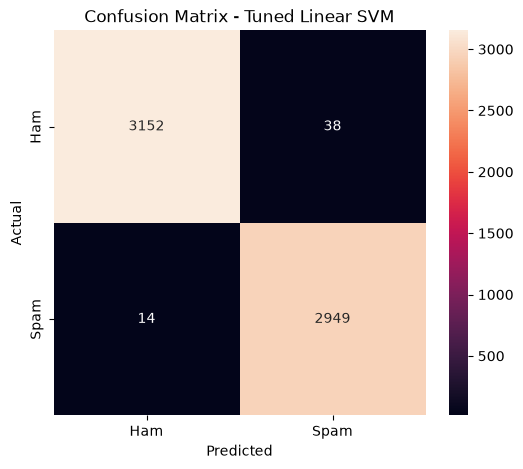

In [53]:
cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned,
    labels=["ham", "spam"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Linear SVM")

plt.show()

In [54]:
errors = df.loc[X_test.index].copy()

errors["Actual"] = y_test
errors["Predicted"] = y_pred_tuned

errors["Error_Type"] = np.where(
    errors["Actual"] != errors["Predicted"],
    "Misclassified",
    "Correct"
)

misclassified = errors[
    errors["Error_Type"] == "Misclassified"
]

print("Total misclassified:", len(misclassified))

Total misclassified: 52


In [55]:
misclassified[
    ["Subject", "Message", "Actual", "Predicted"]
].head(20)

,Subject,Message,Actual,Predicted
16830,so . . . you were looking for a one night stan...,dc,ham,spam
26847,special delivery from marble slab creamery !,you have been sent a virtual marble slab cream...,ham,spam
11776,philippe ideas # 1,anything to do with topo gigio ( a well known ...,ham,spam
14386,marketers,we are dropping a lot of marketers . it would ...,ham,spam
10492,nymex invitation - learn power trading,power trading\nfundamentals :\nsept 15 - 16 ny...,spam,ham
22155,somewhere to live . . . . .,"so , would you recommend anywhere ?\nb .",ham,spam
5235,a basic idea of price - offer matching clauses,vince -\nhere is the basic idea i was alluding...,ham,spam
8478,best picks,"hey ,\nbest picks are zigo and smtx\nsteve",ham,spam
11299,dynegy ' s letter to san diego gas & electric,http : / / biz . yahoo . com / bw / 010413 / 0...,ham,spam
13778,all eta ' s link,this is the hyperlink to all active eta ' s - ...,ham,spam


In [56]:
false_positives = errors[
    (errors["Actual"] == "ham") &
    (errors["Predicted"] == "spam")
]

print("False Positives:", len(false_positives))

false_positives[
    ["Subject", "Message", "Actual", "Predicted"]
]

False Positives: 38


,Subject,Message,Actual,Predicted
16830,so . . . you were looking for a one night stan...,dc,ham,spam
26847,special delivery from marble slab creamery !,you have been sent a virtual marble slab cream...,ham,spam
11776,philippe ideas # 1,anything to do with topo gigio ( a well known ...,ham,spam
14386,marketers,we are dropping a lot of marketers . it would ...,ham,spam
22155,somewhere to live . . . . .,"so , would you recommend anywhere ?\nb .",ham,spam
5235,a basic idea of price - offer matching clauses,vince -\nhere is the basic idea i was alluding...,ham,spam
8478,best picks,"hey ,\nbest picks are zigo and smtx\nsteve",ham,spam
11299,dynegy ' s letter to san diego gas & electric,http : / / biz . yahoo . com / bw / 010413 / 0...,ham,spam
13778,all eta ' s link,this is the hyperlink to all active eta ' s - ...,ham,spam
126,fw : quips,"> remember , amateurs built the ark .\n> > pro...",ham,spam


In [57]:
false_negatives = errors[
    (errors["Actual"] == "spam") &
    (errors["Predicted"] == "ham")
]

print("False Negatives:", len(false_negatives))

false_negatives[
    ["Subject", "Message", "Actual", "Predicted"]
]

False Negatives: 14


,Subject,Message,Actual,Predicted
10492,nymex invitation - learn power trading,power trading\nfundamentals :\nsept 15 - 16 ny...,spam,ham
18941,tpntfhb up ~ d _ ate : medi ~ cal mar ` v _ el,boorgaten bekorstte aggregaat\nfda approved me...,spam,ham
20189,report,? }\n,spam,ham
14904,follow - up crm software,"good morning ,\ni ' m following up on an email...",spam,ham
3574,smoke 9885,cgfsaw 91 cmdaawlolmrlbw 9 rcmlob 3 muz 3 i =\...,spam,ham
26921,advs,"greetings ,\ni am benedicta lindiwe hendricks ...",spam,ham
20454,kluwer alerts is now springer alerts,"dear kluwer alert subscribers ,\nas a result o...",spam,ham
20513,re : invitation for review a paper for the iee...,"giorgo\nefxaristo pou apodektikes .\nan thes ,...",spam,ham
21886,fw :,NaN,spam,ham
28498,want someone to relieve the pressure on your s...,"let ' s , go to the fairwe ' ll walk hand in h...",spam,ham


## Error Analysis

The tuned Linear SVM misclassified 52 out of 6,153 test emails:
- 38 false positives
- 14 false negatives

### False Positives
Common patterns included:
- Legitimate promotional or marketing emails
- Forwarded emails
- Short emails with limited context
- Emails containing words commonly associated with spam

### False Negatives
Common patterns included:
- Spam written in a professional/business style
- Obfuscated or distorted spam text
- Emails with very little textual content
- Emails with missing message bodies
- Multilingual or unusual text

### Conclusion
The remaining classification errors are largely associated with ambiguous,
short, obfuscated, or context-dependent email content. This suggests that
pure word-level TF-IDF features have limitations when the email's meaning
depends on context, word structure, or unusual text patterns.

In [58]:
results.append({
    "Model": "Tuned Linear SVM",
    "Accuracy": accuracy_tuned,
    "Precision": precision_tuned,
    "Recall": recall_tuned,
    "F1 Score": f1_tuned
})

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.983098,0.987718,0.977050,0.982355
1,Logistic Regression,0.983748,0.973536,0.993250,0.983294
2,Linear SVM,0.990086,0.984636,0.994938,0.989760
3,Tuned Linear SVM,0.991549,0.987278,0.995275,0.991261


In [59]:
import joblib

model_path = "../models/spam_classifier_svm.joblib"

joblib.dump(best_svm, model_path)

print(f"Model saved to: {model_path}")

Model saved to: ../models/spam_classifier_svm.joblib


In [60]:
loaded_model = joblib.load("../models/spam_classifier_svm.joblib")

test_email = """
Congratulations! You have won a $1000 cash prize.
Click the link to claim your reward now.
"""

prediction = loaded_model.predict([test_email])

print("Prediction:", prediction[0])

Prediction: spam
